<a href="https://colab.research.google.com/github/Yu202523/DM2026-Assignment-1/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

# 1. 掛載硬碟
drive.mount('/content/drive')

# 2. 切換到該 ipynb 所在的資料夾路徑
# 請根據你的雲端硬碟實際路徑修改
path = "/content/drive/MyDrive/DM2026-Assignment-1"
os.chdir(path)

# 3. 驗證是否看到 model 資料夾
print("目前路徑內容:", os.listdir())

Mounted at /content/drive
目前路徑內容: ['README.md', '.gitignore', 'model', '.git', 'data', 'Linear_Regression.ipynb', 'Real_World_Classification.ipynb', 'Logistic_Regression.ipynb']


In [2]:
%matplotlib inline
import importlib
import model.gradients
importlib.reload(model.gradients)
import model.metrics
importlib.reload(model.metrics)

<module 'model.metrics' from '/content/drive/MyDrive/DM2026-Assignment-1/model/metrics.py'>

In [3]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

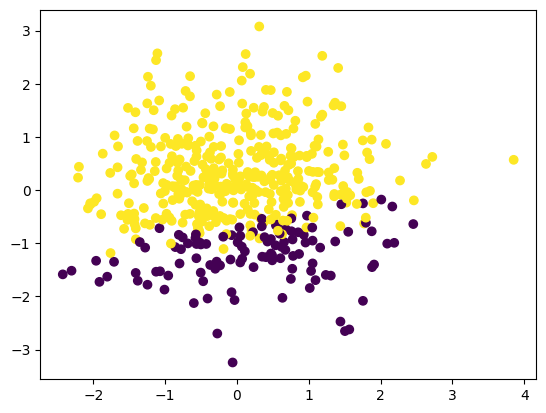

In [4]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [66]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


50. Training loss: 0.42788681156341524, Val loss:0.4289337233194825
100. Training loss: 0.3186543688258759, Val loss:0.330744022589277
150. Training loss: 0.2756136848389012, Val loss:0.2918366320362445
200. Training loss: 0.2515647449518196, Val loss:0.27001137334938924
250. Training loss: 0.23586370599134487, Val loss:0.2557354638551537
300. Training loss: 0.2246778376496635, Val loss:0.24556151612210977
350. Training loss: 0.21624915555159713, Val loss:0.2379013150251245
400. Training loss: 0.20964409595419933, Val loss:0.23190816484103668
450. Training loss: 0.20431563313153664, Val loss:0.2270843249497499
500. Training loss: 0.19991967899618934, Val loss:0.22311586759002253


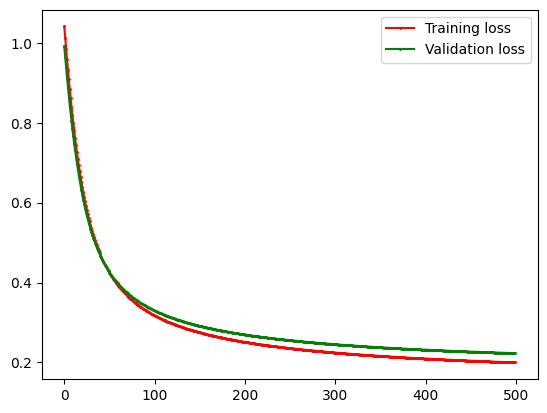

In [71]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.1,n_iteration =500,val_ratio=0.2)

In [72]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9050
Precision : 0.9087
Recall    : 0.9171
F1-score  : 0.9128


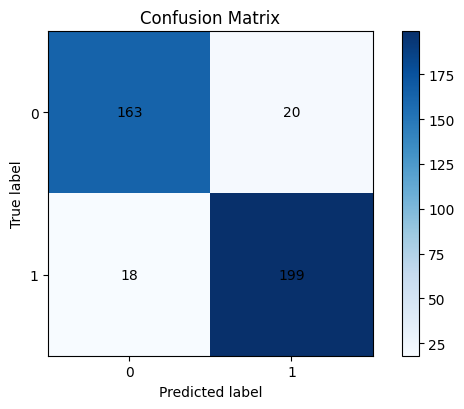

{'Accuracy': 0.905,
 'Precision': 0.908675799086758,
 'Recall': 0.9170506912442397,
 'F1-score': 0.9128440366972477}

In [73]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

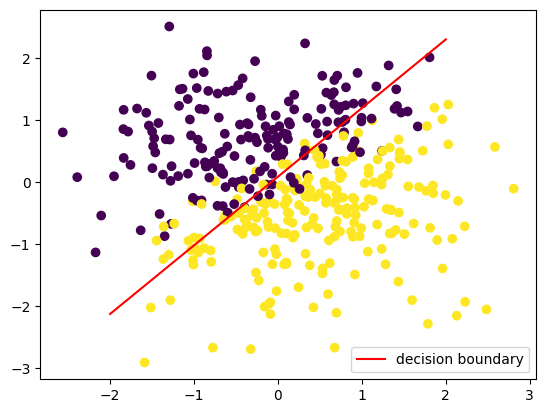

In [9]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()